# Can a short collision overturn monotonic age layers?

This notebook is a deliberately small full-Stokes test of the surge/collision hypothesis for the Allan Hills cul-de-sac. Two ice streams enter a 5 km long, 1 km thick domain from opposite sides. The collision is an instantaneous, strongly compressional end member; the traction-free upper boundary exports the compensating mass. We ask whether 30 years of advection through the solved velocity field converts an initially monotonic age field into an **old–Pleistocene–older** vertical sequence.

This is a mechanism test, not a reconstruction of Allan Hills. Length is in m, time in yr, velocity in m yr$^{-1}$, stress in Pa, and age in Ma.

## Equations and boundary conditions

We solve the actual two-dimensional, incompressible, linear-viscous Stokes equations

$$-\nabla\cdot(2\eta\,\mathrm{sym}\nabla\mathbf u-p\mathbf I)=\rho\mathbf g,\qquad \nabla\cdot\mathbf u=0,$$

with a mixed continuous P2 vector velocity / P1 pressure element. The weak form retains the full symmetric velocity gradient; no shallow approximation or prescribed interior velocity is used. We take $\eta=10^{13}$ Pa yr, $\rho=917$ kg m$^{-3}$, and $g=9.81$ m s$^{-2}$. The bed is no slip. At each side, the inward speed has the no-slip-compatible profile $U(2z/H-(z/H)^2)$, with $U_L=30$ and $U_R=20$ m yr$^{-1}$. The upper boundary has natural zero traction. It is therefore an outflow, not a steady free surface; the short particle integration is interpreted as a transient collision snapshot.

For a layer with slope $m$, [Waddington, Bolzan, and Alley (2001)](https://doi.org/10.3189/172756501781831756) give the kinematic rotation relation

$$\frac{Dm}{Dt}=-m^2u_z-m(u_x-w_z)+w_x.$$

Thus transverse variation $w_x$ must first wrinkle a horizontal layer; vertical shear $u_z$ can then overturn a finite slope. Compression by itself is not sufficient.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Unable to import recommended hash.*")

from firedrake import *
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from IPython.display import Markdown, display

L, H = 5_000.0, 1_000.0
eta, rho, gravity = 1.0e13, 917.0, 9.81
U_left, U_right = 30.0, 20.0
solver_parameters = {
    'mat_type': 'aij', 'ksp_type': 'preonly', 'pc_type': 'lu',
    'pc_factor_mat_solver_type': 'superlu_dist',
}

def solve_stokes(nx, nz):
    mesh = RectangleMesh(nx, nz, L, H, quadrilateral=False)
    V = VectorFunctionSpace(mesh, 'CG', 2)
    Q = FunctionSpace(mesh, 'CG', 1)
    Z = V * Q
    solution = Function(Z, name='velocity_pressure')
    u, p = split(solution)
    v, q = TestFunctions(Z)
    z = SpatialCoordinate(mesh)[1]
    profile = 2.0 * z / H - (z / H)**2
    bcs = [
        DirichletBC(Z.sub(0), as_vector(( U_left * profile, 0.0)), 1),
        DirichletBC(Z.sub(0), as_vector((-U_right * profile, 0.0)), 2),
        DirichletBC(Z.sub(0), Constant((0.0, 0.0)), 3),
    ]
    body_force = as_vector((0.0, -rho * gravity))
    F = (2.0 * eta * inner(sym(grad(u)), sym(grad(v)))
         - p * div(v) - q * div(u)) * dx - dot(body_force, v) * dx
    solve(F == 0, solution, bcs=bcs, solver_parameters=solver_parameters)
    velocity, pressure = solution.subfunctions

    C1 = FunctionSpace(mesh, 'CG', 1)
    V1 = VectorFunctionSpace(mesh, 'CG', 1)
    velocity_p1 = Function(V1).interpolate(velocity)
    shear = Function(C1).interpolate(velocity[0].dx(1))
    wrinkle = Function(C1).interpolate(velocity[1].dx(0))
    normal_strain = Function(C1).interpolate(velocity[0].dx(0) - velocity[1].dx(1))
    normal = FacetNormal(mesh)
    flux = np.array([assemble(dot(velocity, normal) * ds(k)) for k in (1, 2, 3, 4)])
    div_l2 = np.sqrt(assemble(div(velocity)**2 * dx))
    grad_l2 = np.sqrt(assemble(inner(grad(velocity), grad(velocity)) * dx))
    incoming = -np.sum(flux[flux < 0.0])
    diagnostics = {
        'mesh': f'{nx} x {nz}',
        'relative_divergence': div_l2 / grad_l2,
        'relative_flux_residual': abs(np.sum(flux)) / incoming,
        'max_shear_per_yr': np.max(np.abs(shear.dat.data_ro)),
        'shear_to_pure_strain': (np.max(np.abs(shear.dat.data_ro + wrinkle.dat.data_ro)) /
                                 np.max(np.abs(normal_strain.dat.data_ro))),
        'flux': flux,
    }
    return {
        'mesh': mesh, 'velocity': velocity, 'pressure': pressure,
        'velocity_p1': velocity_p1, 'shear': shear, 'wrinkle': wrinkle,
        'normal_strain': normal_strain, 'diagnostics': diagnostics,
    }

coarse = solve_stokes(15, 3)
fine = solve_stokes(30, 6)

In [2]:
print('Mesh-factor-of-two diagnostic')
print('mesh     ||div u||/||grad u||   flux residual   max |du/dz| [yr^-1]   shear/strain')
for case in (coarse, fine):
    d = case['diagnostics']
    print(f"{d['mesh']:8s} {d['relative_divergence']:19.3e} "
          f"{d['relative_flux_residual']:15.3e} {d['max_shear_per_yr']:21.3e} "
          f"{d['shear_to_pure_strain']:14.2f}")
print('Fine-mesh outward boundary fluxes [m^2 yr^-1], left/right/bed/top:')
print(np.array2string(fine['diagnostics']['flux'], precision=2))

Mesh-factor-of-two diagnostic
mesh     ||div u||/||grad u||   flux residual   max |du/dz| [yr^-1]   shear/strain
15 x 3             4.408e-02       1.091e-15             6.000e-02           1.13
30 x 6             2.555e-02       8.731e-16             6.003e-02           0.96
Fine-mesh outward boundary fluxes [m^2 yr^-1], left/right/bed/top:
[-20000.   -13333.33      0.    33333.33]


In [3]:
def velocity_interpolator(case):
    mesh = case['mesh']
    xy = mesh.coordinates.dat.data_ro.copy()
    uv = case['velocity_p1'].dat.data_ro.copy()
    triangles = mesh.coordinates.function_space().cell_node_map().values.copy()
    triangulation = mtri.Triangulation(xy[:, 0], xy[:, 1], triangles)
    iu = mtri.LinearTriInterpolator(triangulation, uv[:, 0])
    iw = mtri.LinearTriInterpolator(triangulation, uv[:, 1])
    def sample(points):
        us = np.ma.filled(iu(points[:, 0], points[:, 1]), np.nan)
        ws = np.ma.filled(iw(points[:, 0], points[:, 1]), np.nan)
        return np.column_stack((us, ws))
    return sample

def advect_layers(case, duration=30.0, dt=0.25, n_x=201, n_z=25):
    x0 = np.linspace(300.0, 4_700.0, n_x)
    z0 = np.linspace(30.0, 600.0, n_z)
    X0, Z0 = np.meshgrid(x0, z0)
    initial = np.column_stack((X0.ravel(), Z0.ravel()))
    position = initial.copy()
    sample = velocity_interpolator(case)
    for _ in range(round(duration / dt)):
        k1 = sample(position)
        k2 = sample(position + 0.5 * dt * k1)
        if not np.all(np.isfinite(k2)):
            raise RuntimeError('A marker left the Stokes domain; shorten the event.')
        position += dt * k2

    # A monotonic, nonlinear age-depth profile: old basal ice and Pleistocene upper ice.
    age = 0.2 + 5.3 * (1.0 - initial[:, 1] / H)**3
    index = np.arange(n_x * n_z).reshape(n_z, n_x)
    triangles = np.vstack((
        np.column_stack((index[:-1, :-1].ravel(), index[:-1, 1:].ravel(), index[1:, 1:].ravel())),
        np.column_stack((index[:-1, :-1].ravel(), index[1:, 1:].ravel(), index[1:, :-1].ravel())),
    ))
    P = position.reshape(n_z, n_x, 2)
    dx_segment = np.diff(P[:, :, 0], axis=1)
    dz_segment = np.diff(P[:, :, 1], axis=1)
    initial_dx = x0[1] - x0[0]
    result = {
        'initial': initial, 'position': position, 'age': age, 'triangles': triangles,
        'shape': (n_z, n_x), 'x0': x0, 'z0': z0,
        'overturned_segments': int(np.count_nonzero(dx_segment < 0.0)),
        'minimum_horizontal_stretch': np.min(dx_segment / initial_dx),
        'maximum_layer_angle_deg': np.degrees(np.max(np.abs(np.arctan2(dz_segment, dx_segment)))),
    }
    return result

coarse_layers = advect_layers(coarse)
fine_layers = advect_layers(fine)
for name, layers in [('coarse', coarse_layers), ('fine', fine_layers)]:
    print(f"{name:6s}: overturned segments = {layers['overturned_segments']}, "
          f"min horizontal stretch = {layers['minimum_horizontal_stretch']:.3f}, "
          f"max layer angle = {layers['maximum_layer_angle_deg']:.1f} deg")

coarse: overturned segments = 0, min horizontal stretch = 0.655, max layer angle = 9.3 deg
fine  : overturned segments = 0, min horizontal stretch = 0.655, max layer angle = 9.9 deg


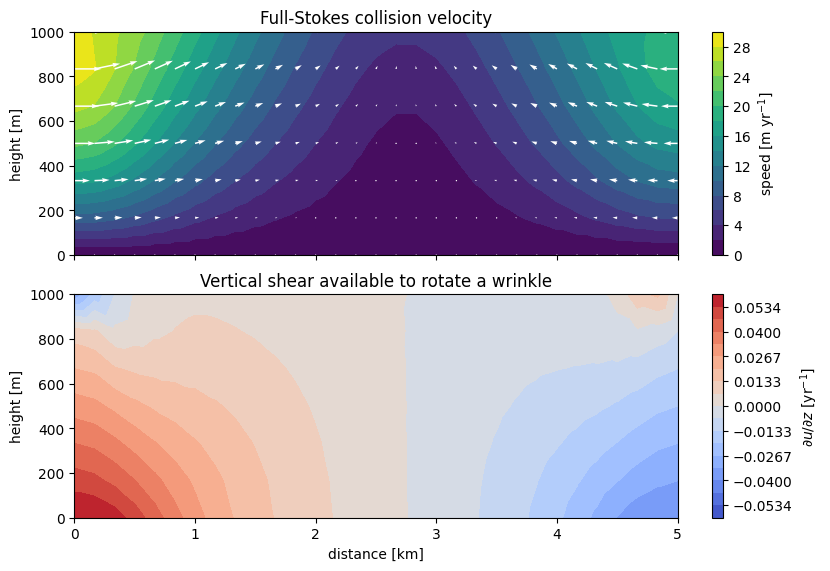

In [4]:
mesh = fine['mesh']
xy = mesh.coordinates.dat.data_ro.copy()
triangles = mesh.coordinates.function_space().cell_node_map().values.copy()
triangulation = mtri.Triangulation(xy[:, 0] / 1_000.0, xy[:, 1], triangles)
uv = fine['velocity_p1'].dat.data_ro.copy()
speed = np.linalg.norm(uv, axis=1)
shear = fine['shear'].dat.data_ro.copy()
fig, axes = plt.subplots(2, 1, figsize=(8.2, 5.6), sharex=True, constrained_layout=True)
c0 = axes[0].tricontourf(triangulation, speed, levels=18, cmap='viridis')
axes[0].quiver(xy[:, 0] / 1_000.0, xy[:, 1], uv[:, 0], uv[:, 1],
               color='white', scale=650, width=0.0025)
fig.colorbar(c0, ax=axes[0], label='speed [m yr$^{-1}$]')
axes[0].set(ylabel='height [m]', title='Full-Stokes collision velocity')
limit = np.max(np.abs(shear))
c1 = axes[1].tricontourf(triangulation, shear, levels=np.linspace(-limit, limit, 19), cmap='coolwarm')
fig.colorbar(c1, ax=axes[1], label=r'$\partial u/\partial z$ [yr$^{-1}$]')
axes[1].set(xlabel='distance [km]', ylabel='height [m]', title='Vertical shear available to rotate a wrinkle')
plt.show()

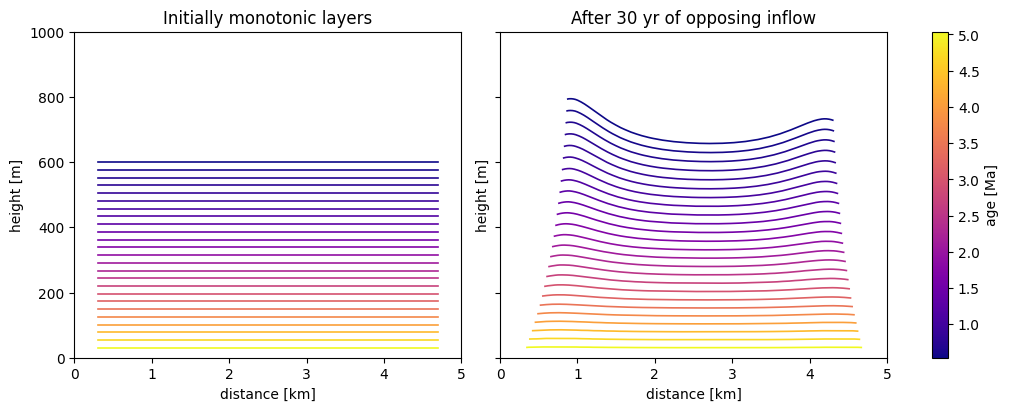

In [5]:
layers = fine_layers
I = layers['initial'].reshape(*layers['shape'], 2)
P = layers['position'].reshape(*layers['shape'], 2)
A = layers['age'].reshape(layers['shape'])
colors = plt.cm.plasma((A[:, 0] - A[:, 0].min()) / np.ptp(A[:, 0]))
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.0), sharex=True, sharey=True, constrained_layout=True)
for j, color in enumerate(colors):
    axes[0].plot(I[j, :, 0] / 1_000.0, I[j, :, 1], color=color, lw=1.2)
    axes[1].plot(P[j, :, 0] / 1_000.0, P[j, :, 1], color=color, lw=1.2)
axes[0].set_title('Initially monotonic layers')
axes[1].set_title('After 30 yr of opposing inflow')
for ax in axes:
    ax.set(xlabel='distance [km]', ylabel='height [m]', xlim=(0, 5), ylim=(0, 1_000))
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(A[:, 0].min(), A[:, 0].max()))
fig.colorbar(sm, ax=axes, label='age [Ma]')
plt.show()

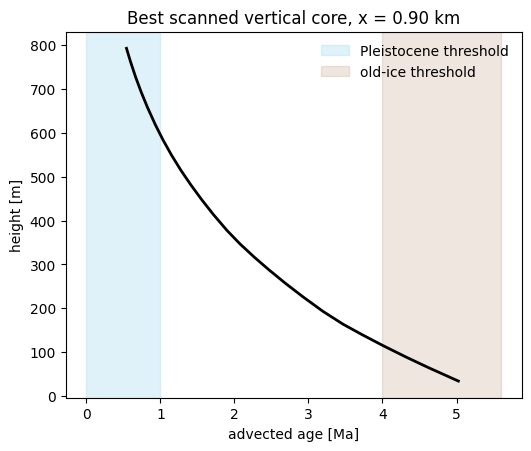

Old–Pleistocene–older criterion: FAIL
Factor-two repeat: FAIL (coarse), FAIL (fine)


In [6]:
def scan_vertical_cores(layers, n_cores=301, n_samples=501):
    pos, age = layers['position'], layers['age']
    material_mesh = mtri.Triangulation(pos[:, 0], pos[:, 1], layers['triangles'])
    age_interpolator = mtri.LinearTriInterpolator(material_mesh, age)
    candidates = []
    for x_core in np.linspace(pos[:, 0].min() + 5.0, pos[:, 0].max() - 5.0, n_cores):
        z = np.linspace(pos[:, 1].min(), pos[:, 1].max(), n_samples)
        a = np.ma.filled(age_interpolator(np.full_like(z, x_core), z), np.nan)
        valid = np.isfinite(a)
        z, a = z[valid], a[valid]
        if len(a) < 5:
            continue
        score, passed = -np.inf, False
        for j in np.where(a <= 1.0)[0]:
            if j == 0 or j == len(a) - 1:
                continue
            below, above = np.max(a[:j]), np.max(a[j + 1:])
            score = max(score, min(below, above) - a[j])
            passed |= (below >= 4.0 and above >= 4.0)
        if not np.isfinite(score):
            score = -np.min(a)
        candidates.append({'x': x_core, 'z': z, 'age': a, 'score': score, 'passed': passed})
    return max(candidates, key=lambda c: (c['passed'], c['score']))

best_coarse = scan_vertical_cores(coarse_layers)
best_fine = scan_vertical_cores(fine_layers)
best = best_fine
fig, ax = plt.subplots(figsize=(5.2, 4.4), constrained_layout=True)
ax.plot(best['age'], best['z'], color='black', lw=2)
ax.axvspan(0, 1, color='#87CEEB', alpha=0.25, label='Pleistocene threshold')
ax.axvspan(4, 5.6, color='#8B4513', alpha=0.13, label='old-ice threshold')
ax.set(xlabel='advected age [Ma]', ylabel='height [m]',
       title=f"Best scanned vertical core, x = {best['x']/1_000:.2f} km")
ax.legend(frameon=False)
plt.show()
print('Old–Pleistocene–older criterion:', 'PASS' if best['passed'] else 'FAIL')
print('Factor-two repeat:', 'PASS' if best_coarse['passed'] else 'FAIL', '(coarse),',
      'PASS' if best_fine['passed'] else 'FAIL', '(fine)')

In [7]:
outcome = 'passes' if best_fine['passed'] else 'does not pass'
display(Markdown(f"""
## Result and limitation

This deliberately strong, short collision **{outcome}** the old–Pleistocene–older test. The fine calculation contains **{fine_layers['overturned_segments']} overturned horizontal layer segments**; its minimum projected horizontal stretch is **{fine_layers['minimum_horizontal_stretch']:.3f}**, and its largest layer angle is **{fine_layers['maximum_layer_angle_deg']:.1f}°**. Thus the age field remains single-valued with height in every scanned core: it is bent and compressed, but not age-reversed. The factor-of-two mesh repeat gives the same categorical outcome.

The Waddington terms clarify the negative result. The solved field has appreciable vertical shear (max $|u_z|={fine['diagnostics']['max_shear_per_yr']:.3f}$ yr$^{{-1}}$), but the collision first produces a broad arch rather than a sufficiently steep wrinkle; shear therefore has too little time to turn a layer through vertical. The result excludes only this simple 30-year, constant-viscosity, opposing-inflow world. Longer forcing cannot be tested in this fixed box without evolving the free surface: the upper boundary already exports **{fine['diagnostics']['flux'][3]:.0f} m² yr$^{{-1}}$** to balance the imposed side inflows. A future positive test would need a physically motivated wrinkle or moving boundary, not an imposed interior velocity.

Most importantly, **no age reversal is produced here**.
"""))


## Result and limitation

This deliberately strong, short collision **does not pass** the old–Pleistocene–older test. The fine calculation contains **0 overturned horizontal layer segments**; its minimum projected horizontal stretch is **0.655**, and its largest layer angle is **9.9°**. Thus the age field remains single-valued with height in every scanned core: it is bent and compressed, but not age-reversed. The factor-of-two mesh repeat gives the same categorical outcome.

The Waddington terms clarify the negative result. The solved field has appreciable vertical shear (max $|u_z|=0.060$ yr$^{-1}$), but the collision first produces a broad arch rather than a sufficiently steep wrinkle; shear therefore has too little time to turn a layer through vertical. The result excludes only this simple 30-year, constant-viscosity, opposing-inflow world. Longer forcing cannot be tested in this fixed box without evolving the free surface: the upper boundary already exports **33333 m² yr$^{-1}$** to balance the imposed side inflows. A future positive test would need a physically motivated wrinkle or moving boundary, not an imposed interior velocity.

Most importantly, **no age reversal is produced here**.
